In [46]:
import pandas as pd
import seaborn as sns
import numpy as np

In [3]:
path="../data/"
language_df = pd.read_csv(path+"language_docs.csv")
framework_df = pd.read_csv(path+"framework_docs.csv")
database_df = pd.read_csv(path+"database_docs.csv")
devops_df = pd.read_csv(path+"devops_docs.csv")
datascience_df = pd.read_csv(path+"datascience_docs.csv")
api_df = pd.read_csv(path+"api_standards_docs.csv")

In [4]:
print("Language Docs:", language_df.shape)
print("Framework Docs:", framework_df.shape)
print("Database Docs:", database_df.shape)
print("DevOps Docs:", devops_df.shape)
print("Data Science Docs:", datascience_df.shape)
print("API Docs:", api_df.shape)

Language Docs: (2700, 14)
Framework Docs: (1680, 14)
Database Docs: (1000, 14)
DevOps Docs: (2500, 14)
Data Science Docs: (3000, 14)
API Docs: (1105, 14)


In [5]:
language_df["doc_category"] = "Language"
framework_df["doc_category"] = "Framework"
database_df["doc_category"] = "Database"
devops_df["doc_category"] = "DevOps"
datascience_df["doc_category"] = "DataScience"
api_df["doc_category"] = "API"


In [6]:
docs_df = pd.concat(
    [
        language_df,
        framework_df,
        database_df,
        devops_df,
        datascience_df,
        api_df
    ],
    ignore_index=True
)

###### Checking Number Of Rows & Columns

In [7]:
docs_df.shape

(11985, 15)

###### Overview Of Data

In [8]:
docs_df.head()

,id,source_url,domain,domain_group,category,title,breadcrumb,content_text,code_examples,tags,agent_role,scraped_at,http_status,content_hash,doc_category
0,python_00001,https://docs.python.org/3/,Python,language_docs,Language Reference,Python 3.14.6 documentation,NaN,Python 3.14.6 documentation Welcome! This is t...,NaN,"docs_by_version,download,navigation,other_reso...",code_agent,2026-06-11T09:20:21.899938,200,0c4128774e38,Language
1,python_00002,https://docs.python.org/3/faq/index.html,Python,language_docs,Language Reference,Python Frequently Asked Questions,NaN,Python Frequently Asked Questions General Pyt...,NaN,"navigation,python,this_page",code_agent,2026-06-11T09:20:23.516889,200,e7e76a418920,Language
2,python_00003,https://docs.python.org/3/reference/index.html,Python,language_docs,Language Reference,The Python Language Reference,NaN,The Python Language Reference This reference ...,NaN,"navigation,python,this_page",code_agent,2026-06-11T09:20:25.128222,200,2ce6bc2bb1c7,Language
3,python_00004,https://docs.python.org/3/howto/index.html,Python,language_docs,Language Reference,Python HOWTOs,NaN,Python HOWTOs Python HOWTOs are documents tha...,NaN,"navigation,python,this_page",code_agent,2026-06-11T09:20:26.738162,200,ceaacad159e3,Language
4,python_00005,https://docs.python.org/3/contents.html,Python,language_docs,Language Reference,Python Documentation contents,NaN,Python Documentation contents Whats New in Py...,build-details.json ||| __annotations__ ||| fro...,"navigation,python,this_page",code_agent,2026-06-11T09:20:28.907020,200,646957027d46,Language


In [9]:
docs_df.tail()

,id,source_url,domain,domain_group,category,title,breadcrumb,content_text,code_examples,tags,agent_role,scraped_at,http_status,content_hash,doc_category
11980,w3c_00496,https://www.w3.org/TR/cssom-view-1/,W3C,api_standards_docs,Web Standards,CSSOM View Module,NaN,CSSOM View Module CSSOM View Module W3C Workin...,VisualViewport ||| VisualViewport ||| matchMed...,"1_background,2_1_css_pixels,2_2_zooming,2_3_we...",architect_agent,2026-06-11T12:58:52.350877,200,327f01d1b3dc,API
11981,w3c_00497,https://www.w3.org/TR/ccxml/,W3C,api_standards_docs,Web Standards,Voice Browser Call Control: CCXML Version 1.0,NaN,Voice Browser Call Control: CCXML Version 1.0 ...,<createconference> ||| <destroyconference> |||...,"1_introduction,2_motivation_informative,3_conc...",architect_agent,2026-06-11T12:58:55.066803,200,212868f67130,API
11982,w3c_00498,https://www.w3.org/TR/epub-a11y-tech-11/,W3C,api_standards_docs,Web Standards,EPUB Accessibility Techniques 1.1,NaN,Abstract EPUB Accessibility Techniques defines...,accessModeSufficient ||| schema:accessMode |||...,"1_1_overview,1_2_terminology,1_introduction,2_...",architect_agent,2026-06-11T12:59:05.511846,200,4cc40de99b34,API
11983,w3c_00499,https://www.w3.org/TR/vcalm-1.0/,W3C,api_standards_docs,Web Standards,VCALM v1.0,NaN,Abstract Verifiable credentials provide a mech...,/credentials/issue ||| /instances/12345/creden...,"1_1_design_goals_and_rationale,1_2_architectur...",architect_agent,2026-06-11T12:59:10.071935,200,aaf7828ef379,API
11984,w3c_00500,https://www.w3.org/TR/media-timed-events/,W3C,api_standards_docs,Web Standards,Requirements for Media Timed Events,NaN,Abstract This document collects use cases and ...,currentTime ||| oncuechange,"1_introduction,2_terminology,3_1_dynamic_conte...",architect_agent,2026-06-11T12:59:12.404549,200,fa38ac65d121,API


#### Removing BreadCrumb And Http Status Field

In [10]:
docs_df.drop('breadcrumb',axis=1,inplace=True)
docs_df.drop('http_status',axis=1,inplace=True)


In [11]:
docs_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11985 entries, 0 to 11984
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             11985 non-null  str  
 1   source_url     11985 non-null  str  
 2   domain         11985 non-null  str  
 3   domain_group   11985 non-null  str  
 4   category       11985 non-null  str  
 5   title          11981 non-null  str  
 6   content_text   11985 non-null  str  
 7   code_examples  10059 non-null  str  
 8   tags           11985 non-null  str  
 9   agent_role     11985 non-null  str  
 10  scraped_at     11985 non-null  str  
 11  content_hash   11985 non-null  str  
 12  doc_category   11985 non-null  str  
dtypes: str(13)
memory usage: 34.8 MB


##### Insights
- There are 13 Object data type columns
- 1 integer columns  - http_status
- Total 11986 rows 

In [12]:
docs_df.columns

Index(['id', 'source_url', 'domain', 'domain_group', 'category', 'title',
       'content_text', 'code_examples', 'tags', 'agent_role', 'scraped_at',
       'content_hash', 'doc_category'],
      dtype='str')

###### Checking  for  duplicated values

In [13]:
docs_df.duplicated().sum()

np.int64(0)

###### Insights 
  --- There is no duplicate value

#### Checking for missing value data

In [14]:
docs_df.isnull().sum()

id                  0
source_url          0
domain              0
domain_group        0
category            0
title               4
content_text        0
code_examples    1926
tags                0
agent_role          0
scraped_at          0
content_hash        0
doc_category        0
dtype: int64

In [15]:
# Category distribution
docs_df["doc_category"].value_counts()


doc_category
DataScience    3000
Language       2700
DevOps         2500
Framework      1680
API            1105
Database       1000
Name: count, dtype: int64

#### Insights

- Data Science is the largest category, contributing 25% of all documents, indicating strong AI/ML knowledge coverage.
- Data Science, Language, and DevOps together account for 68% of the corpus, making software engineering the primary focus area.
- The category distribution is relatively balanced, with no single domain exceeding 25%, reducing retrieval bias.
- Database and API categories have the lowest representation, suggesting opportunities for future data enrichment.
- The six distinct categories naturally support a multi-agent RAG architecture, enabling domain-specific query routing and retrieval.

In [16]:
summary_df = pd.DataFrame({
    "Dataset": [
        "Language",
        "Framework",
        "Database",
        "DevOps",
        "DataScience",
        "API"
    ],
    "Rows": [
        len(language_df),
        len(framework_df),
        len(database_df),
        len(devops_df),
        len(datascience_df),
        len(api_df)
    ]
})

print(summary_df)

       Dataset  Rows
0     Language  2700
1    Framework  1680
2     Database  1000
3       DevOps  2500
4  DataScience  3000
5          API  1105


In [ ]:
docs_df['doc_length'] = docs_df['content_text'].str.len()

In [18]:
docs_df['doc_length'].describe().T

count    11985.000000
mean      2296.847142
std        976.076365
min         54.000000
25%       1532.000000
50%       3000.000000
75%       3000.000000
max       3000.000000
Name: doc_length, dtype: float64

<Axes: xlabel='doc_length', ylabel='Count'>

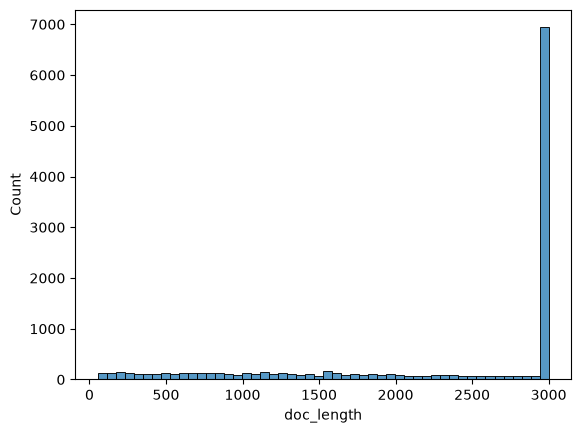

In [19]:
sns.histplot(
    docs_df['doc_length'],
    bins=50
)

##### Word Count 

In [20]:
docs_df['word_count'] = (
    docs_df['content_text']
    .str.split()
    .str.len()
)

In [21]:
docs_df['word_count'].describe()

count    11985.000000
mean       356.384481
std        158.937276
min          5.000000
25%        231.000000
50%        430.000000
75%        477.000000
max        763.000000
Name: word_count, dtype: float64

Insights from Word Count Analysis
- The dataset contains 11,985 documents with an average of 356 words per document, indicating moderately detailed technical content.
- The median word count is 430 words, which is higher than the mean, suggesting the presence of some shorter documents pulling the average downward.
- Document sizes vary considerably (5 to 763 words), demonstrating a mix of brief references and comprehensive technical guides.
- 75% of documents contain fewer than 477 words, indicating that most documentation is concise and suitable for efficient retrieval and embedding.
- The relatively high standard deviation (159 words) highlights content diversity, supporting the need for adaptive chunking strategies to optimize retrieval performance across different document lengths.

##### Source Domain Analysis

In [22]:
docs_df['domain'].value_counts()

domain
JavaScript       500
Java             500
Go               500
Rust             500
C#/.NET          500
Django           500
Ruby on Rails    500
PostgreSQL       500
MySQL            500
Kubernetes       500
Docker           500
Git              500
Terraform        500
Ansible          500
NumPy            500
Pandas           500
SciPy            500
Scikit-learn     500
TensorFlow       500
Matplotlib       500
MDN Web          500
W3C              500
Express          216
Python           200
React            184
Laravel          122
Swagger           93
Vue.js            83
Flask             75
OpenAPI           12
Name: count, dtype: int64

#### Tag Analysis

In [23]:
all_tags = (
    docs_df['tags']
    .dropna()
)

In [24]:
all_tags

0        docs_by_version,download,navigation,other_reso...
1                              navigation,python,this_page
2                              navigation,python,this_page
3                              navigation,python,this_page
4                              navigation,python,this_page
                               ...                        
11980    1_background,2_1_css_pixels,2_2_zooming,2_3_we...
11981    1_introduction,2_motivation_informative,3_conc...
11982    1_1_overview,1_2_terminology,1_introduction,2_...
11983    1_1_design_goals_and_rationale,1_2_architectur...
11984    1_introduction,2_terminology,3_1_dynamic_conte...
Name: tags, Length: 11985, dtype: str

In [25]:
docs_df['agent_role'].value_counts()

agent_role
code_agent         8880
cicd_agent         2500
architect_agent     605
Name: count, dtype: int64


- Finding 1

    - The dataset contains approximately 12,000 documentation records spanning APIs, programming languages, frameworks, databases, DevOps, and data science domains.

- Finding 2

    - Documents are distributed across multiple technical domains, justifying the use of specialized retrieval agents.

- Finding 3

    - Document lengths vary considerably, requiring chunking before embedding and retrieval.

- Finding 4

    - Metadata fields such as domain, tags, category, and agent_role provide strong support for intelligent routing and filtering.

- Finding 5

    - The corpus is suitable for building a Retrieval-Augmented Generation (RAG) system backed by pgvector and a multi-agent orchestration layer.

##### Preprocessing 

In [29]:
# checking data where title is null
docs_df[docs_df['title'].isna()]

,id,source_url,domain,domain_group,category,title,content_text,code_examples,tags,agent_role,scraped_at,content_hash,doc_category,doc_length,word_count
349,javascript_00075,https://developer.mozilla.org/en-US/docs/Web/J...,JavaScript,language_docs,Language Reference,NaN,null - JavaScript | MDN Skip to main content S...,function getVowels(str) {\n const m = str.mat...,"browser_compatibility,description,difference_b...",code_agent,2026-06-11T09:29:31.334377,d1b2275b6049,Language,2591,413
392,javascript_00096,https://developer.mozilla.org/en-US/docs/Web/J...,JavaScript,language_docs,Language Reference,NaN,NaN - JavaScript | MDN Skip to main content Sk...,function sanitize(x) {\n if (isNaN(x)) {\n ...,"description,examples,javascript,observably_dis...",code_agent,2026-06-11T09:30:07.222578,c22521ab3e9e,Language,3000,514
11126,mdn_web_00142,https://developer.mozilla.org/en-US/docs/Web/J...,MDN Web,api_standards_docs,Web Standards,NaN,null - JavaScript | MDN Skip to main content S...,function getVowels(str) {\n const m = str.mat...,"browser_compatibility,description,difference_b...",code_agent,2026-06-11T12:21:39.113240,d1b2275b6049,API,2591,413
11148,mdn_web_00164,https://developer.mozilla.org/en-US/docs/Web/J...,MDN Web,api_standards_docs,Web Standards,NaN,NaN - JavaScript | MDN Skip to main content Sk...,function sanitize(x) {\n if (isNaN(x)) {\n ...,"description,examples,mdn_web,observably_distin...",code_agent,2026-06-11T12:22:16.800180,c22521ab3e9e,API,3000,514


In [31]:
docs_df[docs_df['code_examples'].isna()]

,id,source_url,domain,domain_group,category,title,content_text,code_examples,tags,agent_role,scraped_at,content_hash,doc_category,doc_length,word_count
0,python_00001,https://docs.python.org/3/,Python,language_docs,Language Reference,Python 3.14.6 documentation,Python 3.14.6 documentation Welcome! This is t...,NaN,"docs_by_version,download,navigation,other_reso...",code_agent,2026-06-11T09:20:21.899938,0c4128774e38,Language,1220,168
1,python_00002,https://docs.python.org/3/faq/index.html,Python,language_docs,Language Reference,Python Frequently Asked Questions,Python Frequently Asked Questions General Pyt...,NaN,"navigation,python,this_page",code_agent,2026-06-11T09:20:23.516889,e7e76a418920,Language,235,35
2,python_00003,https://docs.python.org/3/reference/index.html,Python,language_docs,Language Reference,The Python Language Reference,The Python Language Reference This reference ...,NaN,"navigation,python,this_page",code_agent,2026-06-11T09:20:25.128222,2ce6bc2bb1c7,Language,2623,380
3,python_00004,https://docs.python.org/3/howto/index.html,Python,language_docs,Language Reference,Python HOWTOs,Python HOWTOs Python HOWTOs are documents tha...,NaN,"navigation,python,this_page",code_agent,2026-06-11T09:20:26.738162,ceaacad159e3,Language,1078,148
5,python_00006,https://docs.python.org/3/library/index.html,Python,language_docs,Language Reference,The Python Standard Library,The Python Standard Library While The Python ...,NaN,"navigation,python,this_page",code_agent,2026-06-11T09:20:31.114188,e4d6879e3293,Language,3000,429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11957,w3c_00473,https://www.w3.org/TR/wcag-em-2/,W3C,api_standards_docs,Web Standards,W3C Accessibility Guidelines Evaluation Method...,Abstract This document describes a methodology...,NaN,"1_1_target_audience,1_2_relation_to_wcag_2_con...",architect_agent,2026-06-11T12:57:17.984613,14140ee0d3be,API,750,107
11961,w3c_00477,https://www.w3.org/TR/ct-landscape/,W3C,api_standards_docs,Web Standards,Content Transformation Landscape 1.0,Content Transformation Landscape 1.0 Content T...,NaN,"1_1_purpose,1_2_scope,1_introduction,abstract,...",architect_agent,2026-06-11T12:57:29.889070,987b48c14c1c,API,3000,449
11970,w3c_00486,https://www.w3.org/TR/ws-arch/,W3C,api_standards_docs,Web Standards,Web Services Architecture,Web Services Architecture Web Services Archite...,NaN,"1_1_purpose_of_the_web_service,1_2_intended_au...",architect_agent,2026-06-11T12:58:07.495086,bb0d59344ac9,API,3000,441
11978,w3c_00494,https://www.w3.org/TR/tibt-gap/,W3C,api_standards_docs,Web Standards,Tibetan Gap Analysis,Abstract This document describes and prioritis...,NaN,"1_1_contributors,1_2_about_this_document,1_3_p...",architect_agent,2026-06-11T12:58:41.685408,67f48a30729b,API,383,62


In [33]:
# handling nan value in title column
docs_df.loc[
    docs_df['title'].isna(),
    'title'
] = (
    docs_df.loc[docs_df['title'].isna(), 'source_url']
    .str.split('/')
    .str[-1]
    .str.replace('-', ' ')
)

In [32]:
# handling nan values in code examples 
docs_df['code_examples'] = docs_df['code_examples'].fillna('No code example available')

In [34]:
docs_df.isna().sum()

id               0
source_url       0
domain           0
domain_group     0
category         0
title            0
content_text     0
code_examples    0
tags             0
agent_role       0
scraped_at       0
content_hash     0
doc_category     0
doc_length       0
word_count       0
dtype: int64

### Missing Value Treatment

#### Handling Missing Values in `title`

The `title` column contained only **4 missing values**, representing less than **0.05%** of the total dataset. Since each record contained a valid source URL, the missing titles were derived from the URL path by extracting the last segment and replacing hyphens with spaces. This approach preserved valuable documentation records while maintaining metadata completeness.

**Reason for Treatment:**
- Prevents unnecessary loss of documentation records.
- Preserves contextual information useful for retrieval and search.
- URL-derived titles provide a meaningful approximation of the original page title.

---

#### Handling Missing Values in `code_examples`

The `code_examples` column contained missing values because not all documentation pages include executable code snippets. Examples include conceptual documentation, FAQs, navigation pages, standards references, and overview pages.

Missing values were replaced with the text **"No code example available"**.

**Reason for Treatment:**
- Distinguishes between genuinely missing data and documents that naturally do not contain code.
- Ensures consistency across all records.
- Prevents null values from causing issues during preprocessing, embedding generation, and retrieval operations.
- Retains all documentation pages in the corpus without introducing misleading information.

---

#### Summary

After preprocessing, all missing values in the selected columns were successfully handled. Missing titles were reconstructed from source URLs, while missing code examples were replaced with a descriptive placeholder. This improved dataset completeness and ensured compatibility with downstream Retrieval-Augmented Generation (RAG), embedding generation, and semantic search workflows.

#### Outlier treatment

In [35]:
Q1 = docs_df["word_count"].quantile(0.25)
Q3 = docs_df["word_count"].quantile(0.75)

IQR = Q3 - Q1

<Axes: xlabel='word_count'>

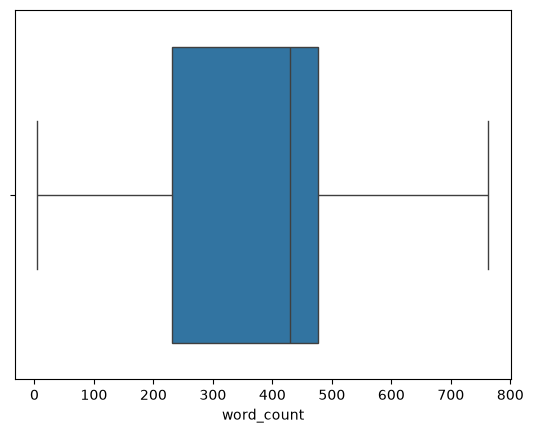

In [36]:
sns.boxplot(data=docs_df,x='word_count')

<Axes: xlabel='doc_length'>

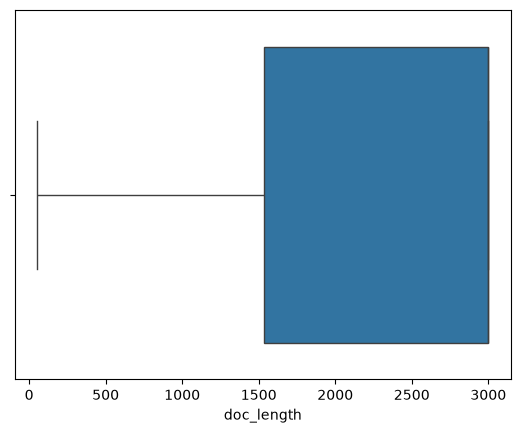

In [37]:
sns.boxplot(data=docs_df,x='doc_length')

#### Outlier Treatment
    
     -  No outliers in docs_length and word_count checked using Boxplot.
    -   If outliers are there we can not remove because long technical documents are often valuable and                  should not be removed.


#### Extensive EDA

##### Relationship Between Documentation Domains and Record Distribution

<Axes: xlabel='count', ylabel='domain'>

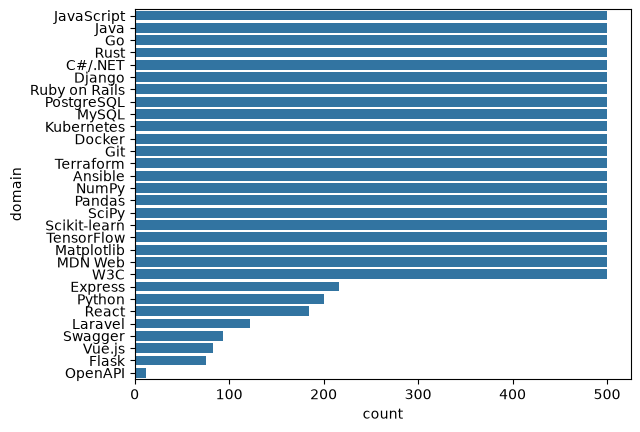

In [39]:
sns.countplot(
    data=docs_df,
    y="domain",
    order=docs_df["domain"].value_counts().index
)

<Axes: xlabel='category', ylabel='domain'>

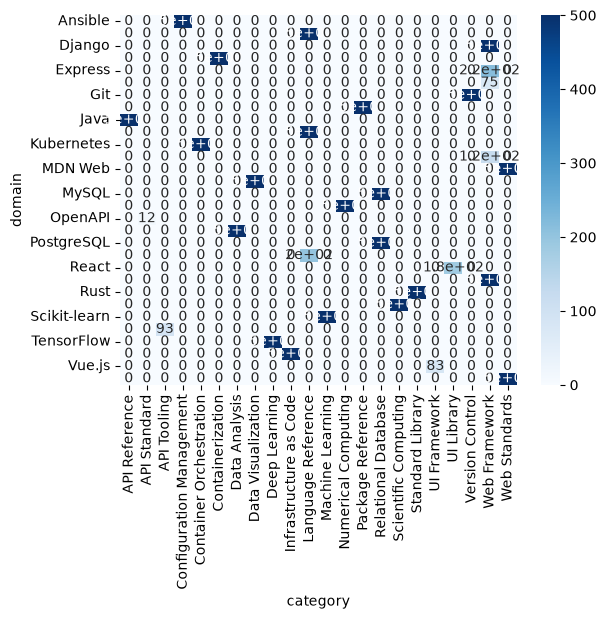

In [40]:
pivot = pd.crosstab(
    docs_df["domain"],
    docs_df["category"]
)

sns.heatmap(
    pivot,
    annot=True,
    cmap="Blues"
)

#### Insights
- Documentation records are highly domain-specific.
- Web development technologies contribute the largest portion of the corpus.
- Infrastructure and DevOps domains form a separate knowledge cluster.
- Machine Learning and Data Science domains are well represented and clearly segmented.
- Category overlap is low, indicating high-quality metadata organization.
- Domain and category metadata can be leveraged for future filtered retrieval.
- The corpus provides comprehensive coverage across major software engineering domains

##### Agent Role Distribution

<Axes: xlabel='count', ylabel='agent_role'>

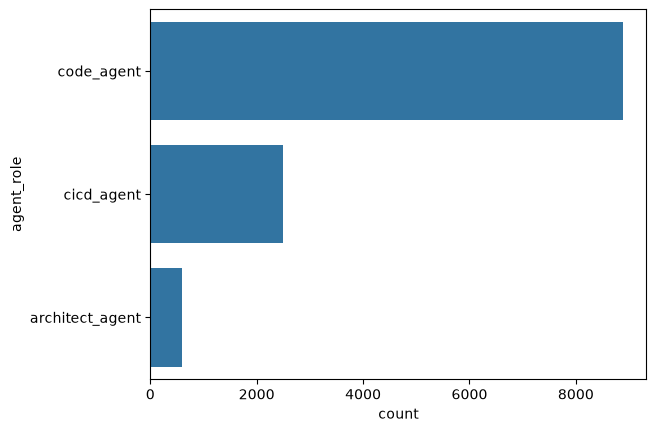

In [43]:
sns.countplot(
    data=docs_df,
    y="agent_role"
)

##### Insights
- code_agent dominates the dataset with approximately 9,000 documents, accounting for nearly 75% of the corpus, indicating a strong focus on programming languages, frameworks, and developer documentation.
- cicd_agent contains around 2,500 documents, representing a substantial knowledge base for DevOps, infrastructure, deployment, and automation-related queries.
- architect_agent has the fewest documents (around 500), suggesting that architecture and design-related content is comparatively limited within the corpus.
- The distribution is intentionally aligned with expected query volumes, where coding and implementation support is likely to be the most common use case, followed by DevOps and architecture guidance.
- The agent-based categorization supports efficient query routing in the Multi-Agent RAG system, enabling programming queries to be directed to code_agent, infrastructure queries to cicd_agent, and design-related queries to architect_agent, improving retrieval relevance and response quality.

#### Relationship Between Code Examples and Content Length

In [44]:
docs_df["has_code_example"] = (
    docs_df["code_examples"]
    .notna()
)

<Axes: xlabel='has_code_example', ylabel='content_length'>

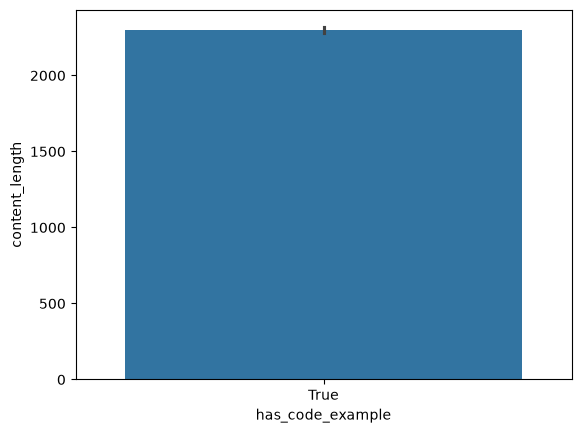

In [45]:
sns.barplot(
    data=docs_df,
    x="has_code_example",
    y="content_length"
)

#### Insights
- Documents with code examples tend to have substantial content length, indicating that code snippets are typically accompanied by detailed explanations.
- The average content length for documents containing code examples is approximately 2,300 characters, suggesting rich technical documentation.
- Code examples are predominantly found in longer documents rather than short reference pages or navigation content.
- The presence of code examples enhances the informational depth of documentation, making such records valuable for retrieval tasks.
- Including the has_code_example feature can improve query filtering by distinguishing conceptual documentation from implementation-focused content.

#### Content Length vs Number of Chunks

In [47]:
docs_df["chunk_count"] = (
    docs_df["content_length"] /
    1000
).apply(np.ceil)

<Axes: xlabel='content_length', ylabel='chunk_count'>

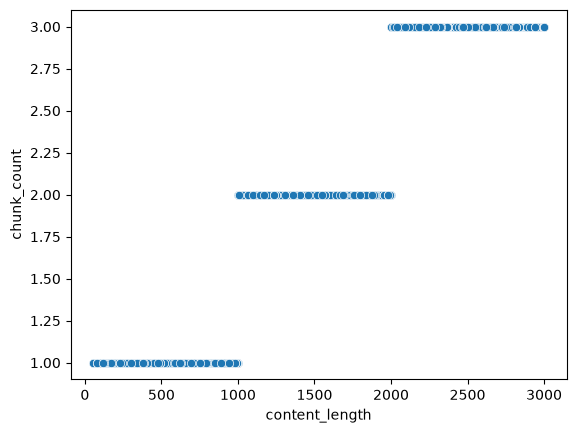

In [48]:
sns.scatterplot(
    data=docs_df,
    x="content_length",
    y="chunk_count"
)

#### Insights
- Document length and chunk count show a clear positive relationship, with longer documents producing more chunks during preprocessing.
- Documents shorter than ~1,000 characters typically generate a single chunk, while longer documents are split into two or three chunks.
- The chunking strategy effectively controls document size, ensuring content is divided into manageable segments for embedding and retrieval.